# Best Model Selection — Next-Year PM2.5 Risk Classification

**Module:** IT3051 - Fundamentals of Data Mining  
**Notebook:** `19_best_model_selection.ipynb`

## What this notebook does

1. Reads the **best hyperparameters** saved by each tuning notebook (`13`, `14`, `16`, `18`) plus the tuned Logistic Regression settings from `17`.
2. Rebuilds every tuned model and trains it on the **training split only**, with the preprocessor fitted on training data only.
3. Evaluates **all five models on the same validation set** with the same metrics.
4. Selects the winner by **validation Macro F1** (tie-breakers: QWK, then balanced accuracy).
5. Evaluates **only the winner** on the held-out test set, once, after the choice is final.
6. Saves the comparison table, report, figures and the final model pipeline.

## Why models are rebuilt instead of loaded

The tuning notebooks save metrics and best-parameter CSVs, not model files. Rebuilding from the saved parameters with `random_state=42` gives the same models, and the notebook checks this against the numbers each tuning notebook saved.

## Selection rules

- Same chronological splits for every model (train ≤ 2012, validation 2013-2014, test 2015+).
- Preprocessor fitted on `X_train` only.
- **Primary metric: validation Macro F1.** The target is imbalanced, and this is the metric the tuning notebooks optimised.
- **Tie-breakers:** QWK (the risk categories are ordered), then balanced accuracy.
- Accuracy is reported but not used to choose, because it rewards predicting the majority class.
- Test labels are never used to choose a model.

In [5]:
import sys, time, json, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, cohen_kappa_score, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

# Find the project root whether Jupyter starts in the root or in notebooks/
current = Path.cwd().resolve()
project_root = next(
    (p for p in (current, *current.parents)
     if (p / "src" / "preprocessing" / "preprocessing_pipeline.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Could not find the project root (a folder containing "
        "src/preprocessing/preprocessing_pipeline.py)."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)

Imports loaded successfully.
Project root: G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project


## 1. Configuration

In [6]:
PROCESSED_DIR = project_root / "data" / "processed"
RESULTS_DIR   = project_root / "reports" / "model_results"
PICTURES_DIR  = project_root / "reports" / "pictures"
MODELS_DIR    = project_root / "models"
for d in (RESULTS_DIR, PICTURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Selection rule -----------------------------------------------------------
PRIMARY_METRIC     = "macro_f1"
TIE_BREAKERS       = ["qwk", "balanced_accuracy", "accuracy"]
SELECTION_ORDER    = [PRIMARY_METRIC] + TIE_BREAKERS
CLOSE_CALL_MARGIN  = 0.01     # flag the choice if the winner leads by less than this

# --- Behaviour switches -------------------------------------------------------
ALLOW_MISSING_MODELS = False  # False = stop if any model's parameters are missing
RUN_FINAL_TEST       = True   # evaluates ONLY the winner, after selection
REPRO_TOLERANCE      = 0.005  # allowed gap vs. the Macro F1 saved by the tuning notebook

# Ordinal order of the risk categories (needed for QWK)
CLASS_ORDER = [
    "Good", "Moderate", "Unhealthy for Sensitive Groups",
    "Unhealthy", "Very Unhealthy", "Hazardous",
]

print("Selection order:", SELECTION_ORDER)

Selection order: ['macro_f1', 'qwk', 'balanced_accuracy', 'accuracy']


## 2. Load Splits and Fit Preprocessing on Training Data Only

In [7]:
paths = {
    "train": PROCESSED_DIR / "train_data.csv",
    "validation": PROCESSED_DIR / "validation_data.csv",
    "test": PROCESSED_DIR / "test_data.csv",
}
for p in paths.values():
    if not p.exists():
        raise FileNotFoundError(f"{p}\nRun 07_make_dataset.ipynb first.")

id_types = {"site_id": "string", "state_code": "string",
            "county_code": "string", "site_num": "string"}

train_df = pd.read_csv(paths["train"],      dtype=id_types, low_memory=False)
val_df   = pd.read_csv(paths["validation"], dtype=id_types, low_memory=False)
test_df  = pd.read_csv(paths["test"],       dtype=id_types, low_memory=False)

if "year" in train_df.columns:
    for name, df in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
        print(f"{name:10s}: {df['year'].min()} - {df['year'].max()}  ({len(df)} rows)")

X_train, y_train = prepare_features_and_target(prepare_base_dataframe(train_df))
X_val,   y_val   = prepare_features_and_target(prepare_base_dataframe(val_df))
X_test,  y_test  = prepare_features_and_target(prepare_base_dataframe(test_df))

# Fit on training data ONLY, then apply to validation and test
preprocessor = build_preprocessor(X_train)
Xtr = preprocessor.fit_transform(X_train)
Xv  = preprocessor.transform(X_val)
Xt  = preprocessor.transform(X_test)

print("\nProcessed shapes:", Xtr.shape, Xv.shape, Xt.shape)
print("\nValidation class counts:")
print(y_val.value_counts())

Training  : 1997 - 2012  (13191 rows)
Validation: 2013 - 2014  (1783 rows)
Test      : 2015 - 2016  (1561 rows)
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Numerical features: 29
Categorical features: 4

Processed shapes: (13191, 2154) (1783, 2154) (1561, 2154)

Validation class cou

## 3. Collect the Tuned Hyperparameters

Parameters for Random Forest, Gradient Boosting, LightGBM and SVM are read from the `*_best_parameters.csv` files written by the tuning notebooks, so this notebook always uses whatever the tuning notebooks actually selected.

Logistic Regression is the exception: notebook `17` does not save its best parameters, so they are copied from its `GridSearchCV` output (`saga`, `l1`, `C=1.0`, `class_weight="balanced"`). If you re-tune it, update the dictionary below.

In [8]:
# ---- converters: CSV text -> Python values --------------------------------------
def _missing(v):
    return v is None or (isinstance(v, float) and np.isnan(v)) or \
           (isinstance(v, str) and v.strip().lower() in ("", "none", "nan"))

def as_int(v):        return int(float(v))
def as_float(v):      return float(v)
def as_opt_int(v):    return None if _missing(v) else int(float(v))
def as_opt_str(v):    return None if _missing(v) else str(v)
def as_gamma(v):
    try:    return float(v)          # numeric gamma
    except (TypeError, ValueError):
        return str(v)                # "scale" / "auto"

def read_best_params(filename, schema):
    path = RESULTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)
    row = pd.read_csv(path).iloc[0]
    return {key: cast(row[key]) for key, cast in schema.items()}

def saved_validation_macro_f1(filename):
    """Macro F1 that the tuning notebook itself saved (used as a reproducibility check)."""
    path = RESULTS_DIR / filename
    if not path.exists():
        return np.nan
    df = pd.read_csv(path)
    col = next((c for c in df.columns if c.lower().replace(" ", "_") == "validation_macro_f1"), None)
    return float(df[col].iloc[0]) if col else np.nan

# ---- one entry per candidate model ---------------------------------------------
MODEL_SPECS = {
    "Logistic Regression": {
        "source": "hard-coded from notebook 17 (GridSearchCV)",
        "params": lambda: dict(solver="saga", penalty="l1", C=1.0, class_weight="balanced"),
        "build":  lambda p: LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, **p),
        "saved_macro_f1": lambda: 0.3485,   # tuned validation Macro F1 printed in notebook 17
    },
    "Random Forest": {
        "source": "random_forest_best_parameters.csv",
        "params": lambda: read_best_params("random_forest_best_parameters.csv", {
            "n_estimators": as_int, "max_depth": as_opt_int,
            "min_samples_leaf": as_int, "class_weight": as_opt_str}),
        "build":  lambda p: RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **p),
        "saved_macro_f1": lambda: saved_validation_macro_f1("random_forest_tuned_results.csv"),
    },
    "Gradient Boosting": {
        "source": "gradient_boosting_best_parameters.csv",
        "params": lambda: read_best_params("gradient_boosting_best_parameters.csv", {
            "n_estimators": as_int, "learning_rate": as_float,
            "max_depth": as_int, "subsample": as_float}),
        "build":  lambda p: GradientBoostingClassifier(random_state=RANDOM_STATE, **p),
        "saved_macro_f1": lambda: saved_validation_macro_f1("gradient_boosting_tuned_results.csv"),
    },
    "LightGBM": {
        "source": "lightgbm_best_parameters.csv",
        "params": lambda: read_best_params("lightgbm_best_parameters.csv", {
            "n_estimators": as_int, "learning_rate": as_float, "num_leaves": as_int,
            "max_depth": as_int, "subsample": as_float, "colsample_bytree": as_float}),
        "build":  lambda p: LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, **p),
        "saved_macro_f1": lambda: saved_validation_macro_f1("lightgbm_tuned_results.csv"),
    },
    "SVM (RBF)": {
        "source": "svm_rbf_best_parameters.csv",
        "params": lambda: read_best_params("svm_rbf_best_parameters.csv", {
            "C": as_float, "gamma": as_gamma, "class_weight": as_opt_str}),
        "build":  lambda p: SVC(kernel="rbf", **p),
        "saved_macro_f1": lambda: saved_validation_macro_f1("svm_rbf_tuned_results.csv"),
    },
}

active_params, missing = {}, []
for name, spec in MODEL_SPECS.items():
    try:
        active_params[name] = spec["params"]()
        print(f"OK       {name:20s} <- {spec['source']}")
        print(f"           {active_params[name]}")
    except FileNotFoundError as e:
        missing.append(name)
        print(f"MISSING  {name:20s} <- {e}")

if missing and not ALLOW_MISSING_MODELS:
    raise FileNotFoundError(
        f"Best-parameter files are missing for: {missing}.\n"
        "Run the corresponding tuning notebook first (13 RF, 14 GB, 16 LightGBM, 18 SVM), "
        "or set ALLOW_MISSING_MODELS = True to compare only the available models."
    )
print(f"\nModels to compare: {list(active_params)}")

OK       Logistic Regression  <- hard-coded from notebook 17 (GridSearchCV)
           {'solver': 'saga', 'penalty': 'l1', 'C': 1.0, 'class_weight': 'balanced'}
OK       Random Forest        <- random_forest_best_parameters.csv
           {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
OK       Gradient Boosting    <- gradient_boosting_best_parameters.csv
           {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8}
OK       LightGBM             <- lightgbm_best_parameters.csv
           {'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 1.0}
OK       SVM (RBF)            <- svm_rbf_best_parameters.csv
           {'C': 5.0, 'gamma': 'scale', 'class_weight': 'balanced'}

Models to compare: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'LightGBM', 'SVM (RBF)']


## 4. Train Every Tuned Model and Evaluate on Validation

All models see the same processed training matrix and are scored on the same validation rows. Convergence warnings are captured so they appear in the table instead of being hidden.

In [9]:
def ordered_labels(*label_sets):
    observed = set()
    for ls in label_sets:
        observed |= set(pd.Series(ls).astype(str))
    labels = [l for l in CLASS_ORDER if l in observed]
    return labels + sorted(observed - set(labels))

def compute_metrics(y_true, y_pred):
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision":   precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall":      recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "qwk":               cohen_kappa_score(y_true, y_pred,
                                 labels=ordered_labels(y_true, y_pred), weights="quadratic"),
    }

fitted_models, val_predictions, rows = {}, {}, []

for name, params in active_params.items():
    print(f"Training {name} ...", end=" ", flush=True)
    model = MODEL_SPECS[name]["build"](params)

    t0 = time.time()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(Xtr, y_train)
    fit_seconds = time.time() - t0
    converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)

    t0 = time.time()
    pred = model.predict(Xv)
    predict_seconds = time.time() - t0

    fitted_models[name], val_predictions[name] = model, pred
    rows.append({"model": name, **compute_metrics(y_val, pred),
                 "fit_seconds": fit_seconds, "predict_seconds": predict_seconds,
                 "converged": converged})
    print(f"done ({fit_seconds:.1f}s)  Macro F1 = {rows[-1]['macro_f1']:.4f}")

val_results = pd.DataFrame(rows)

Training Logistic Regression ... done (785.4s)  Macro F1 = 0.3485
Training Random Forest ... done (6.7s)  Macro F1 = 0.4091
Training Gradient Boosting ... done (100.7s)  Macro F1 = 0.3884
Training LightGBM ... done (4.5s)  Macro F1 = 0.3825
Training SVM (RBF) ... done (32.5s)  Macro F1 = 0.4364


## 5. Reproducibility Check

Each rebuilt model should match the validation Macro F1 that its tuning notebook saved. A large gap means the data, library versions or parameters differ from the tuning run, and the comparison should not be trusted until it is explained.

In [10]:
check = val_results[["model", "macro_f1"]].rename(columns={"macro_f1": "rebuilt_macro_f1"})
check["saved_macro_f1"] = check["model"].map(lambda m: MODEL_SPECS[m]["saved_macro_f1"]())
check["difference"] = check["rebuilt_macro_f1"] - check["saved_macro_f1"]
check["status"] = np.where(
    check["saved_macro_f1"].isna(), "no saved value to compare",
    np.where(check["difference"].abs() <= REPRO_TOLERANCE, "OK", "MISMATCH - investigate"))
display(check.round(4))

if (check["status"] == "MISMATCH - investigate").any():
    print("WARNING: at least one model does not reproduce its tuning-notebook result.")
if not val_results["converged"].all():
    print("NOTE: these models raised convergence warnings:",
          list(val_results.loc[~val_results["converged"], "model"]))

,model,rebuilt_macro_f1,saved_macro_f1,difference,status
0,Logistic Regression,0.3485,0.3485,-0.0,OK
1,Random Forest,0.4091,0.4091,0.0,OK
2,Gradient Boosting,0.3884,0.3884,0.0,OK
3,LightGBM,0.3825,0.3825,0.0,OK
4,SVM (RBF),0.4364,0.4364,0.0,OK


NOTE: these models raised convergence warnings: ['Logistic Regression']


## 6. Rank the Models and Select the Winner

Sorted by validation Macro F1, then QWK, then balanced accuracy.

In [11]:
ranking = (val_results.sort_values(SELECTION_ORDER, ascending=False)
                      .reset_index(drop=True))
ranking.insert(0, "rank", ranking.index + 1)

show_cols = ["rank", "model", "macro_f1", "qwk", "balanced_accuracy", "accuracy",
             "weighted_f1", "macro_precision", "macro_recall", "fit_seconds", "converged"]
display(ranking[show_cols].round(4))

best_name   = ranking.loc[0, "model"]
best_row    = ranking.loc[0]
best_params = active_params[best_name]

print(f"\nSELECTED MODEL : {best_name}")
print(f"Parameters     : {best_params}")
print(f"Validation Macro F1 : {best_row['macro_f1']:.4f}")
print(f"Validation QWK      : {best_row['qwk']:.4f}")

if len(ranking) > 1:
    gap = best_row[PRIMARY_METRIC] - ranking.loc[1, PRIMARY_METRIC]
    print(f"Lead over runner-up ({ranking.loc[1, 'model']}): {gap:+.4f} {PRIMARY_METRIC}")
    if gap < CLOSE_CALL_MARGIN:
        print("CLOSE CALL: the lead is small. Validation has few rare-class rows, "
              "so treat this ranking as indicative.")

,rank,model,macro_f1,qwk,balanced_accuracy,accuracy,weighted_f1,macro_precision,macro_recall,fit_seconds,converged
0,1,SVM (RBF),0.4364,0.4850,0.4300,0.7549,0.7198,0.5032,0.4300,32.5288,True
1,2,Random Forest,0.4091,0.5165,0.4172,0.7650,0.7229,0.6158,0.4172,6.6846,True
2,3,Gradient Boosting,0.3884,0.4827,0.3774,0.7650,0.7259,0.4516,0.3774,100.6766,True
3,4,LightGBM,0.3825,0.4615,0.3404,0.7656,0.7203,0.5769,0.3404,4.4692,True
4,5,Logistic Regression,0.3485,0.4340,0.4629,0.7213,0.6851,0.4008,0.4629,785.3510,False



SELECTED MODEL : SVM (RBF)
Parameters     : {'C': 5.0, 'gamma': 'scale', 'class_weight': 'balanced'}
Validation Macro F1 : 0.4364
Validation QWK      : 0.4850
Lead over runner-up (Random Forest): +0.0273 macro_f1


### Robustness: does the winner change under a different metric?

If one model leads on every metric, the choice is solid. If the ranking flips, the decision depends on the metric chosen and should be justified in the report.

In [12]:
metric_cols = ["macro_f1", "qwk", "balanced_accuracy", "accuracy", "weighted_f1"]
rank_table = ranking.set_index("model")[metric_cols].rank(ascending=False, method="min").astype(int)
rank_table["mean_rank"] = rank_table.mean(axis=1)
display(rank_table.sort_values("mean_rank"))

leaders = {m: ranking.sort_values(m, ascending=False).iloc[0]["model"] for m in metric_cols}
print("Leader per metric:", leaders)

,macro_f1,qwk,balanced_accuracy,accuracy,weighted_f1,mean_rank
model,,,,,,
Random Forest,2,1,3,2,2,2.0
SVM (RBF),1,2,2,4,4,2.6
Gradient Boosting,3,3,4,2,1,2.6
LightGBM,4,4,5,1,3,3.4
Logistic Regression,5,5,1,5,5,4.2


Leader per metric: {'macro_f1': 'SVM (RBF)', 'qwk': 'Random Forest', 'balanced_accuracy': 'Logistic Regression', 'accuracy': 'LightGBM', 'weighted_f1': 'Gradient Boosting'}


## 7. Validation Comparison Chart

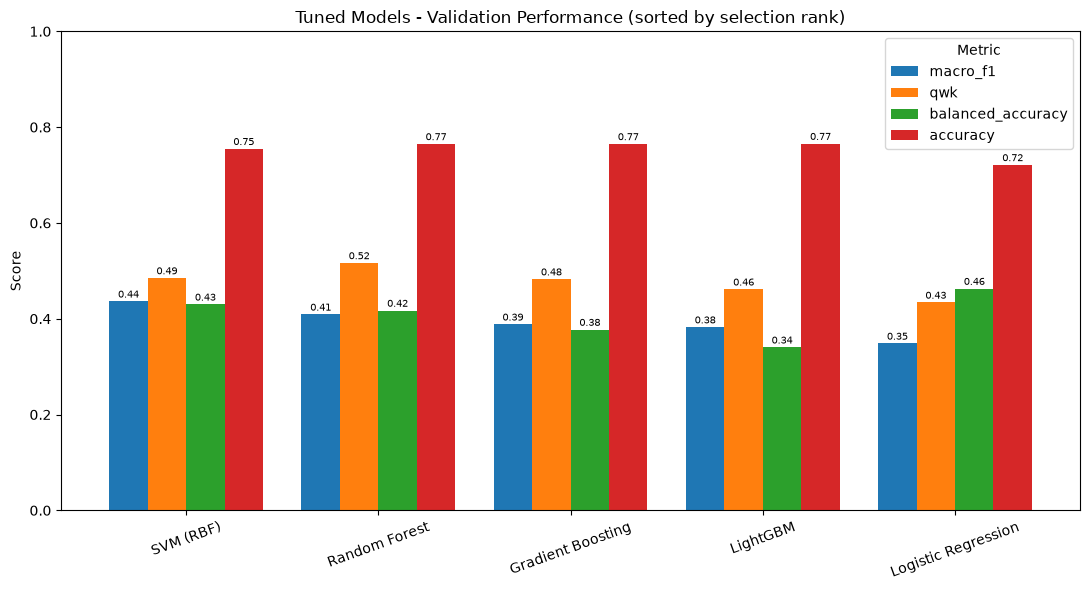

In [13]:
plot_metrics = ["macro_f1", "qwk", "balanced_accuracy", "accuracy"]
plot_df = ranking.set_index("model")[plot_metrics]

ax = plot_df.plot(kind="bar", figsize=(11, 6), rot=20, width=0.8)
ax.set_title("Tuned Models - Validation Performance (sorted by selection rank)")
ax.set_ylabel("Score"); ax.set_xlabel("")
ax.set_ylim(0, max(1.0, float(plot_df.values.max()) + 0.05))
ax.legend(title="Metric", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout()
comparison_plot_path = PICTURES_DIR / "best_model_validation_comparison.png"
plt.savefig(comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()

## 8. Per-Class Diagnostics

Macro F1 averages over classes, so a model can score well by handling the common classes while failing the rare, high-risk ones. The table shows F1 per risk category for every model.

,SVM (RBF),Random Forest,Gradient Boosting,LightGBM,Logistic Regression,validation_support
Good,0.364,0.286,0.143,0.333,0.070,5
Moderate,0.870,0.878,0.874,0.875,0.852,1282
Unhealthy for Sensitive Groups,0.309,0.287,0.334,0.310,0.201,356
Unhealthy,0.416,0.451,0.410,0.394,0.428,127
Very Unhealthy,0.222,0.143,0.182,0.000,0.190,13


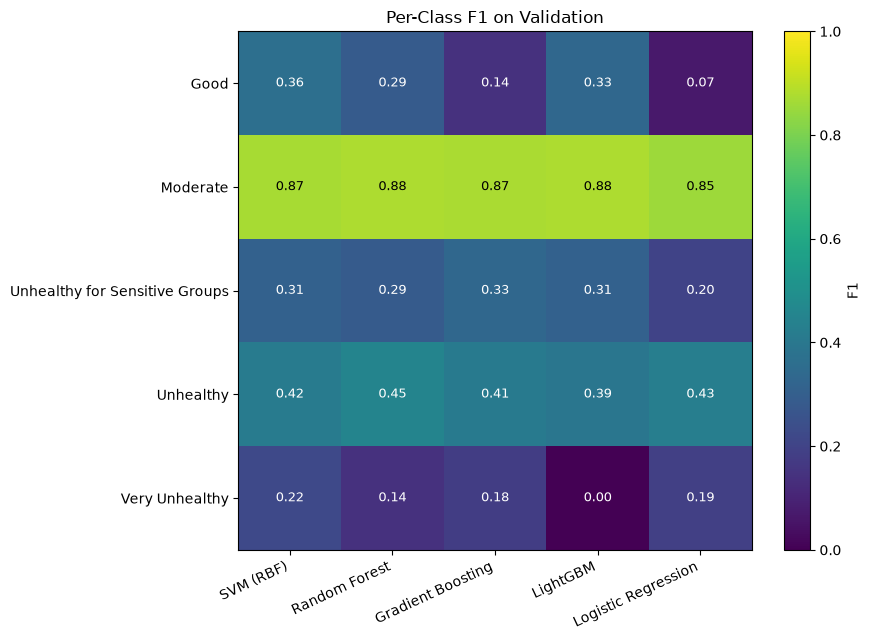

In [14]:
class_labels = ordered_labels(y_val, *val_predictions.values())

per_class = pd.DataFrame({
    name: f1_score(y_val, pred, labels=class_labels, average=None, zero_division=0)
    for name, pred in val_predictions.items()
}, index=class_labels)
per_class = per_class[ranking["model"].tolist()]
per_class["validation_support"] = pd.Series(y_val).value_counts().reindex(class_labels).fillna(0).astype(int)
display(per_class.round(3))

fig, ax = plt.subplots(figsize=(9, 0.9 * len(class_labels) + 2))
data = per_class.drop(columns="validation_support")
im = ax.imshow(data.values, vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(data.columns, rotation=25, ha="right")
ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(data.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data.values[i, j]:.2f}", ha="center", va="center",
                color="white" if data.values[i, j] < 0.6 else "black", fontsize=9)
ax.set_title("Per-Class F1 on Validation")
fig.colorbar(im, ax=ax, label="F1")
plt.tight_layout()
per_class_plot_path = PICTURES_DIR / "best_model_per_class_f1_validation.png"
plt.savefig(per_class_plot_path, dpi=300, bbox_inches="tight")
plt.show()

## 9. Selected Model - Validation Detail

SVM (RBF) - validation classification report
                                precision    recall  f1-score   support

                          Good       0.33      0.40      0.36         5
                      Moderate       0.81      0.94      0.87      1282
Unhealthy for Sensitive Groups       0.58      0.21      0.31       356
                     Unhealthy       0.39      0.44      0.42       127
                Very Unhealthy       0.40      0.15      0.22        13

                      accuracy                           0.75      1783
                     macro avg       0.50      0.43      0.44      1783
                  weighted avg       0.73      0.75      0.72      1783



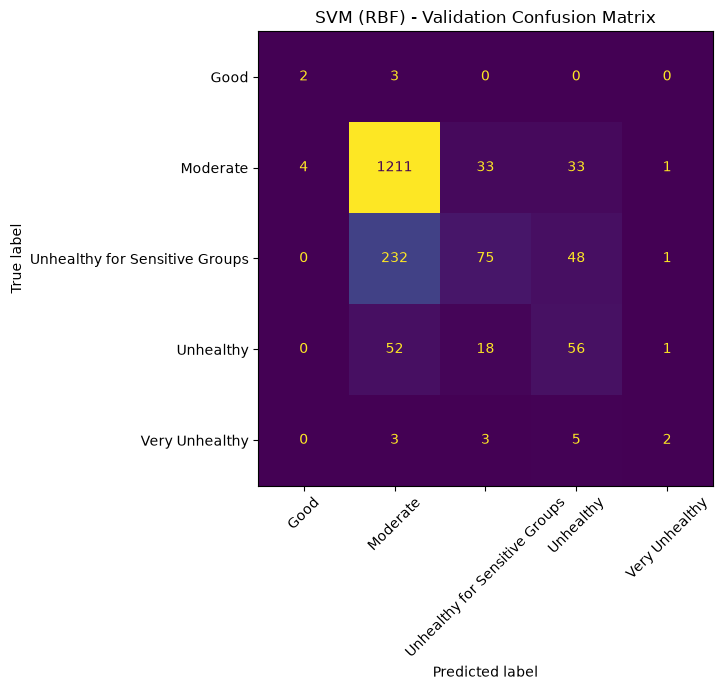

In [15]:
best_val_pred = val_predictions[best_name]

print(f"{best_name} - validation classification report")
print(classification_report(y_val, best_val_pred, labels=class_labels, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val, best_val_pred, labels=class_labels, xticks_rotation=45,
    values_format="d", colorbar=False, ax=ax)
ax.set_title(f"{best_name} - Validation Confusion Matrix")
plt.tight_layout()
val_cm_path = PICTURES_DIR / "best_model_confusion_matrix_validation.png"
plt.savefig(val_cm_path, dpi=300, bbox_inches="tight")
plt.show()

## 10. Final Test Evaluation (Selected Model Only)

The model has now been chosen using validation results alone. The test set is used here once, for the winner only, to estimate how it performs on later years. **Do not go back and change the choice based on these numbers.**

SVM (RBF) - validation vs. test


,validation,test,test_minus_validation
accuracy,0.7549,0.7924,0.0375
balanced_accuracy,0.4300,0.2968,-0.1332
macro_precision,0.5032,0.3593,-0.1439
macro_recall,0.4300,0.2968,-0.1332
macro_f1,0.4364,0.2945,-0.1419
weighted_f1,0.7198,0.7786,0.0588
qwk,0.4850,0.4014,-0.0836


                                precision    recall  f1-score   support

                          Good       0.40      0.07      0.12        29
                      Moderate       0.88      0.92      0.90      1287
Unhealthy for Sensitive Groups       0.33      0.16      0.21       173
                     Unhealthy       0.19      0.34      0.24        68
                Very Unhealthy       0.00      0.00      0.00         4

                      accuracy                           0.79      1561
                     macro avg       0.36      0.30      0.29      1561
                  weighted avg       0.78      0.79      0.78      1561



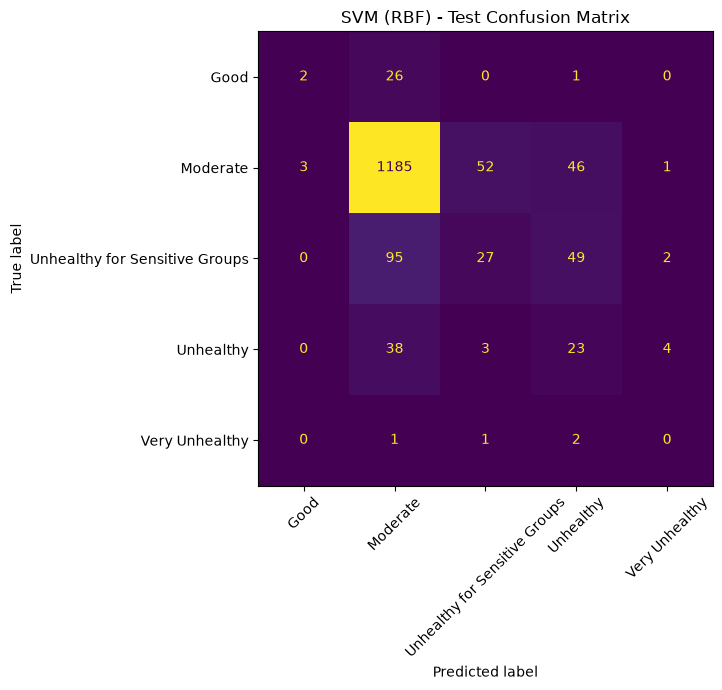

In [16]:
test_metrics, test_report_df, test_cm_path = None, None, None

if RUN_FINAL_TEST:
    best_model = fitted_models[best_name]
    test_pred = best_model.predict(Xt)
    test_metrics = compute_metrics(y_test, test_pred)

    test_labels = ordered_labels(y_test, test_pred)
    test_report_df = pd.DataFrame(
        classification_report(y_test, test_pred, labels=test_labels,
                              output_dict=True, zero_division=0)).T

    val_vs_test = pd.DataFrame({
        "validation": {m: best_row[m] for m in test_metrics},
        "test": test_metrics,
    })
    val_vs_test["test_minus_validation"] = val_vs_test["test"] - val_vs_test["validation"]
    print(f"{best_name} - validation vs. test")
    display(val_vs_test.round(4))
    print(classification_report(y_test, test_pred, labels=test_labels, zero_division=0))

    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay.from_predictions(
        y_test, test_pred, labels=test_labels, xticks_rotation=45,
        values_format="d", colorbar=False, ax=ax)
    ax.set_title(f"{best_name} - Test Confusion Matrix")
    plt.tight_layout()
    test_cm_path = PICTURES_DIR / "best_model_confusion_matrix_test.png"
    plt.savefig(test_cm_path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("RUN_FINAL_TEST is False - test set not evaluated.")

## 11. Save Results and the Final Model

The saved `.joblib` file is a complete pipeline (fitted preprocessor + fitted classifier) that accepts raw feature columns, as produced by `prepare_features_and_target`.

In [17]:
# --- tables -------------------------------------------------------------------
comparison_csv = RESULTS_DIR / "best_model_validation_comparison.csv"
ranking.to_csv(comparison_csv, index=False)

per_class_csv = RESULTS_DIR / "best_model_per_class_f1_validation.csv"
per_class.to_csv(per_class_csv)

summary = {
    "selected_model": best_name,
    "selection_metric": PRIMARY_METRIC,
    "tie_breakers": ", ".join(TIE_BREAKERS),
    "parameters": json.dumps(best_params, default=str),
    **{f"validation_{k}": best_row[k] for k in
       ["macro_f1", "qwk", "balanced_accuracy", "accuracy", "weighted_f1"]},
}
if test_metrics is not None:
    summary.update({f"test_{k}": v for k, v in test_metrics.items()})
summary_csv = RESULTS_DIR / "best_model_summary.csv"
pd.DataFrame([summary]).to_csv(summary_csv, index=False)

test_report_csv = None
if test_report_df is not None:
    test_report_csv = RESULTS_DIR / "best_model_test_classification_report.csv"
    test_report_df.to_csv(test_report_csv)

# --- final model pipeline -----------------------------------------------------
final_pipeline = Pipeline([("preprocessor", preprocessor),
                           ("classifier", fitted_models[best_name])])
best_model_path = MODELS_DIR / "best_model.joblib"
joblib.dump(final_pipeline, best_model_path)

# --- markdown report ----------------------------------------------------------
def md_table(df):
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "|".join(["---"] * len(cols)) + "|"]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(f"{v:.4f}" if isinstance(v, float) else str(v) for v in r) + " |")
    return "\n".join(lines)

report_lines = [
    "# Best Model Selection Report", "",
    "## Decision", "",
    f"**Selected model: {best_name}**", "",
    f"- Parameters: `{best_params}`",
    f"- Selection rule: validation {PRIMARY_METRIC}; ties broken by {', '.join(TIE_BREAKERS)}.",
    f"- Validation Macro F1: {best_row['macro_f1']:.4f} | QWK: {best_row['qwk']:.4f} | "
    f"Balanced accuracy: {best_row['balanced_accuracy']:.4f} | Accuracy: {best_row['accuracy']:.4f}",
]
if len(ranking) > 1:
    report_lines.append(f"- Lead over runner-up ({ranking.loc[1, 'model']}): "
                        f"{best_row[PRIMARY_METRIC] - ranking.loc[1, PRIMARY_METRIC]:+.4f} {PRIMARY_METRIC}")
report_lines += ["", "## Validation comparison (all tuned models)", "",
                 md_table(ranking[show_cols]), ""]
if test_metrics is not None:
    report_lines += ["## Test performance of the selected model", "",
                     md_table(pd.DataFrame([{"model": best_name, **test_metrics}])), "",
                     "The test set was used once, after the model was chosen on validation results."]
report_lines += ["", "## Method notes", "",
                 "- All models used the same chronological train/validation/test split.",
                 "- The preprocessor was fitted on training data only.",
                 "- Models were rebuilt from the tuned hyperparameters with random_state=42.",
                 "- Test labels were not used for tuning or model selection."]
report_path = RESULTS_DIR / "best_model_selection_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved.")

Saved.


## 12. Output Check

In [18]:
expected = [comparison_csv, per_class_csv, summary_csv, report_path, best_model_path,
            comparison_plot_path, per_class_plot_path, val_cm_path]
if RUN_FINAL_TEST:
    expected += [test_report_csv, test_cm_path]

for p in expected:
    print(("OK     " if Path(p).exists() else "MISSING"), "-", p)

print()
print(f"FINAL SELECTION: {best_name}")
print("IMPORTANT: Selection used validation Macro F1 (tie-breakers: QWK, balanced accuracy).")
print("IMPORTANT: Preprocessor fitted on training data only.")
print("IMPORTANT: Test set was evaluated once, for the selected model only.")

OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\best_model_validation_comparison.csv
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\best_model_per_class_f1_validation.csv
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\best_model_summary.csv
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\best_model_selection_report.md
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\models\best_model.joblib
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\best_model_validation_comparison.png
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\best_model_per_class_f1_validation.png
OK      - G:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\best_model_confusion_m